# 02 — Reward decomposition

Where did the agent's total return come from?  The runner records
both the **sum** and the **mean** of every enabled reward component
per episode (``reward_sum/<name>`` and ``reward_mean/<name>``).

In [1]:
import sys, pathlib
# Make ``utils.py`` importable whether the notebook is opened from
# project root or from analysis/.
_here = pathlib.Path.cwd()
for cand in (_here, _here / "analysis", _here.parent):
    if (cand / "utils.py").exists():
        sys.path.insert(0, str(cand))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    list_runs, latest_run, load_run, load_runs,
    group_columns, group_columns_by_prefix, strip_prefix, rolling_mean,
)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 200)

In [2]:
# Pick a run.  ``latest_run()`` returns the most recently modified
# experiment in ``reports/``.  Override ``EXP_ID = "..."`` to analyse
# a specific one.
EXP_ID = latest_run()
print("Analysing:", EXP_ID)

ep, st, cfg = load_run(EXP_ID)
print(f"  episode_metrics.csv: shape={ep.shape}")
print(f"  step_metrics.csv:    shape={st.shape if st is not None else 'absent'}")

Analysing: nb_least_busy
  episode_metrics.csv: shape=(3, 104)
  step_metrics.csv:    shape=(75, 49)


## Cumulative contribution per component (training)

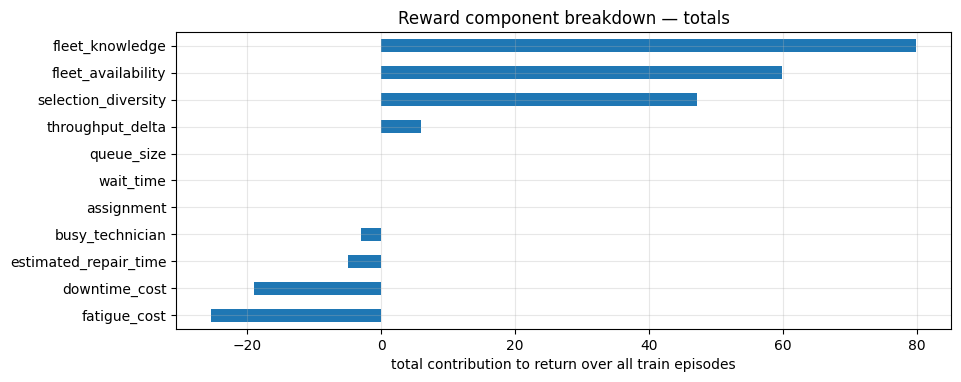

In [3]:
train = ep[ep["phase"] == "train"]
sum_cols = group_columns(train, "reward_sum")
contribs = train[sum_cols].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, max(3, 0.35 * len(contribs))))
contribs.plot.barh(ax=ax)
ax.set(xlabel="total contribution to return over all train episodes",
       title="Reward component breakdown — totals")
ax.set_yticklabels(strip_prefix(list(contribs.index), "reward_sum"))
plt.show()

## Reward-component evolution over episodes

Stacked area: each episode's return decomposed by component.  Helps
identify whether one component dominates (e.g. `assignment` runs
positive while `wait_time` runs negative).

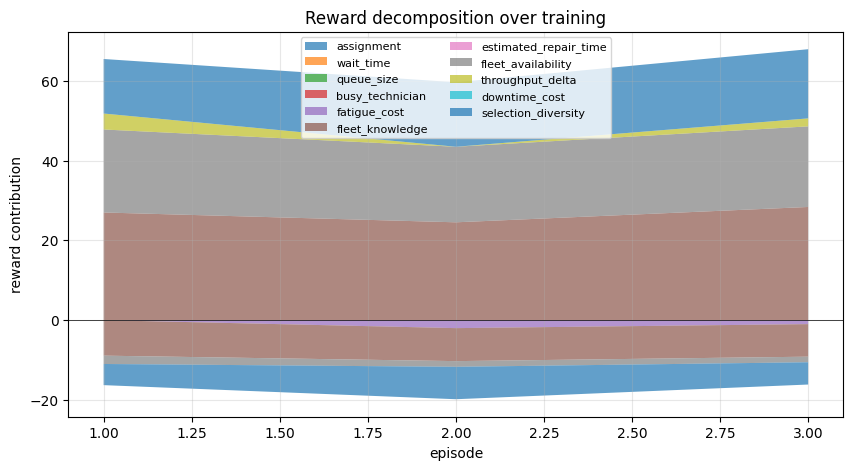

In [4]:
labels = strip_prefix(sum_cols, "reward_sum")
stacked = train[sum_cols].copy()
stacked.columns = labels

# Separate positive and negative components so the plot isn't dominated
# by the zero line
pos = stacked.clip(lower=0)
neg = stacked.clip(upper=0)

fig, ax = plt.subplots()
ax.stackplot(train["episode"], pos.T, labels=pos.columns, alpha=0.7)
ax.stackplot(train["episode"], neg.T, alpha=0.7)
ax.axhline(0, color="k", lw=0.5)
ax.set(xlabel="episode", ylabel="reward contribution", title="Reward decomposition over training")
ax.legend(loc="best", fontsize=8, ncol=2)
plt.show()

## Mean per-step component values

In [5]:
mean_cols = group_columns(train, "reward_mean")
mean_df = train[mean_cols].agg(["mean", "std"]).T
mean_df.index = strip_prefix(list(mean_df.index), "reward_mean")
mean_df.sort_values("mean", ascending=False).round(4)

,mean,std
fleet_knowledge,1.0649,0.0779
fleet_availability,0.7991,0.0381
selection_diversity,0.6289,0.0749
throughput_delta,0.0800,0.0800
assignment,0.0000,0.0000
wait_time,0.0000,0.0000
queue_size,0.0000,0.0000
busy_technician,-0.0400,0.0400
estimated_repair_time,-0.0655,0.0156
downtime_cost,-0.2534,0.0622
